# German Credit Data

## Data Dictionary (Grouped by Feature Type)

This section provides an overview of all variables in the South German Credit dataset, grouped by their statistical nature.  
The coding schemes follow the original dataset documentation.

---

### Numerical Features (Quantitative)

**laufzeit** (`duration`)  
- Credit duration in months  

**hoehe** (`amount`)  
- Credit amount in Deutsche Mark (DM)  
- Result of a monotonic transformation (exact transformation unknown)  

**alter** (`age`)  
- Age of the debtor in years  

---

### Ordinal Features (Ordered, Discretized Quantitative)

**laufkont** (`status`) — Status of checking account  
- 1 : no checking account  
- 2 : balance < 0 DM  
- 3 : 0 ≤ balance < 200 DM  
- 4 : balance ≥ 200 DM or salary for at least 1 year  

**beszeit** (`employment_duration`) — Employment duration  
- 1 : unemployed  
- 2 : < 1 year  
- 3 : 1 ≤ … < 4 years  
- 4 : 4 ≤ … < 7 years  
- 5 : ≥ 7 years  

**rate** (`installment_rate`) — Installment rate (% of disposable income)  
- 1 : ≥ 35%  
- 2 : 25% ≤ … < 35%  
- 3 : 20% ≤ … < 25%  
- 4 : < 20%  

**wohnzeit** (`present_residence`) — Length of residence  
- 1 : < 1 year  
- 2 : 1 ≤ … < 4 years  
- 3 : 4 ≤ … < 7 years  
- 4 : ≥ 7 years  

**verm** (`property`) — Most valuable property  
- 1 : unknown / no property  
- 2 : car or other  
- 3 : building society savings agreement / life insurance  
- 4 : real estate  

**bishkred** (`number_credits`) — Number of credits at this bank  
- 1 : 1  
- 2 : 2–3  
- 3 : 4–5  
- 4 : ≥ 6  

**beruf** (`job`) — Job quality  
- 1 : unemployed / unskilled (non-resident)  
- 2 : unskilled (resident)  
- 3 : skilled employee / official  
- 4 : manager / self-employed / highly qualified employee  

---

### Categorical Features (Nominal, Unordered)

**moral** (`credit_history`) — Credit history  
- 0 : delay in paying off in the past  
- 1 : critical account / other credits elsewhere  
- 2 : no credits taken or all credits paid back duly  
- 3 : existing credits paid back duly till now  
- 4 : all credits at this bank paid back duly  

**verw** (`purpose`) — Credit purpose  
- 0 : others  
- 1 : car (new)  
- 2 : car (used)  
- 3 : furniture / equipment  
- 4 : radio / television  
- 5 : domestic appliances  
- 6 : repairs  
- 7 : education  
- 8 : vacation  
- 9 : retraining  
- 10 : business  

**sparkont** (`savings`) — Savings account  
- 1 : unknown / no savings account  
- 2 : < 100 DM  
- 3 : 100 ≤ … < 500 DM  
- 4 : 500 ≤ … < 1000 DM  
- 5 : ≥ 1000 DM  

**famges** (`personal_status_sex`) — Personal status and sex (combined)  
- 1 : male, divorced / separated  
- 2 : female non-single or male single  
- 3 : male, married / widowed  
- 4 : female, single  

**buerge** (`other_debtors`) — Other debtors or guarantor  
- 1 : none  
- 2 : co-applicant  
- 3 : guarantor  

**weitkred** (`other_installment_plans`) — Other installment plans  
- 1 : bank  
- 2 : stores  
- 3 : none  

**wohn** (`housing`) — Housing type  
- 1 : for free  
- 2 : rent  
- 3 : own  

---

### Binary Features

**pers** (`people_liable`) — Number of people liable for maintenance  
- 1 : 3 or more  
- 2 : 0 to 2  

**telef** (`telephone`) — Telephone registered in debtor’s name  
- 1 : no  
- 2 : yes  

**gastarb** (`foreign_worker`) — Foreign worker status  
- 1 : yes  
- 2 : no  

---

### Target Variable

**default** (derived from `kredit`) — Credit risk outcome  
- `default = 1` : bad credit / default  
- `default = 0` : good credit / non-default  

The original variable `kredit` (`0 = bad`, `1 = good`) was transformed and removed to avoid ambiguity and to align with standard credit-risk modeling conventions.


## Imports

In [ ]:
# --- Standard library ---
import sys
import os

sys.path.append("..")

# --- Third-party libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Project configuration ---
from config import (
    COLUMN_RENAME_MAP,
    NUMERICAL_FEATURES,
    ORDINAL_FEATURES,
    CATEGORICAL_FEATURES,
    BINARY_FEATURES
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## Read and show data

In [7]:
df = pd.read_csv("../data/raw/german_credit_data.csv")
df.head()


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


### Rename Columns

In [9]:
df = df.rename(columns=COLUMN_RENAME_MAP)
df.columns


Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration',
       'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker',
       'kredit'],
      dtype='str')

### Label distribution

In [10]:
df["kredit"].value_counts()


kredit
1    700
0    300
Name: count, dtype: int64

### Derive default target

In [11]:
df["default"] = 1 - df["kredit"]

In [12]:
df["default"].value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [ ]:
default_rate = df["default"].mean()
print(f"Default rate: {default_rate:.1%}")

### Drop source label column

In [14]:
df = df.drop(columns=["kredit"])

## Closer look at numerical features

In [15]:
df[["duration", "amount", "age"]].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
age,1000.0,35.542,11.352670,19.0,27.0,33.0,42.00,75.0


In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10))

for ax, col in zip(axes, ["duration", "amount", "age"]):
    ax.hist(df[col], bins=30, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Count")

axes[-1].set_xlabel("Value")
plt.suptitle("Distributions of Numerical Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # preserve space for suptitle
plt.show()

**duration** — discrete peaks at common loan terms (12, 18, 24, 36, 48 months); right-skewed up to 72 months. Treat as numeric.

**amount** — strong right skew; most loans are small with a long upper tail. Scaling required for logistic regression.

**age** — roughly bell-shaped with right tail; no implausible values (19–75). No cleaning needed.

### Boxplots by default

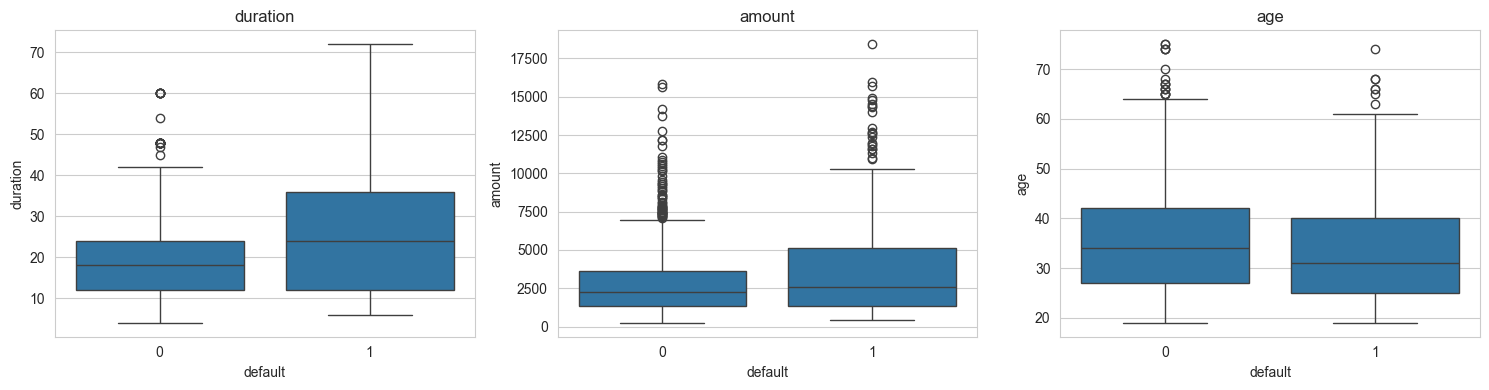

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, ["duration", "amount", "age"]):
    sns.boxplot(x="default", y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


### Default rate by quantiles

In [18]:
for col in ["duration", "amount", "age"]:
    df[f"{col}_bin"] = pd.qcut(df[col], q=5, duplicates="drop")
    print(f"\nDefault rate by {col} quintiles:")
    print(df.groupby(f"{col}_bin")["default"].mean())



Default rate by duration quintiles:
duration_bin
(3.999, 12.0]    0.211699
(12.0, 15.0]     0.180556
(15.0, 24.0]     0.321534
(24.0, 30.0]     0.333333
(30.0, 72.0]     0.479769
Name: default, dtype: float64

Default rate by amount quintiles:
amount_bin
(249.999, 1262.0]    0.303483
(1262.0, 1906.8]     0.241206
(1906.8, 2852.4]     0.270000
(2852.4, 4720.0]     0.260000
(4720.0, 18424.0]    0.425000
Name: default, dtype: float64

Default rate by age quintiles:
age_bin
(18.999, 26.0]    0.393305
(26.0, 30.0]      0.317647
(30.0, 36.0]      0.256881
(36.0, 44.0]      0.264368
(44.0, 75.0]      0.251256
Name: default, dtype: float64


### Risk relationships

- **Duration** — strong positive monotonic relationship with default (21% → 48% across quintiles); key risk driver.
- **Amount** — tail-risk effect; highest quintile defaults at ~42.5% vs. ~25–30% for lower quintiles.
- **Age** — highest risk for youngest borrowers (~39%), decreasing and flattening beyond ~30 years; non-linear effect.

## Closer look at ordinal features

In [19]:
# Ordinal features
ordinal_features = [
    "status",
    "employment_duration",
    "installment_rate",
    "present_residence",
    "property",
    "number_credits",
    "job"
]

# Helper function for pretty formatting
def pretty_ordinal_table(df_summary, n_obs):
    df_out = (
        df_summary
        .assign(
            default_rate=lambda x: (x["default_rate"] * 100).round(1),
            share=lambda x: (x["count"] / n_obs * 100).round(1)
        )
        .rename(
            columns={
                "count": "Count",
                "default_rate": "Default rate (%)",
                "share": "Share (%)"
            }
        )
    )
    df_out.index.name = "Level"
    return df_out


# Compute + display summaries
ordinal_summaries = {}

for col in ordinal_features:
    summary = (
        df
        .groupby(col)
        .agg(
            count=("default", "size"),
            default_rate=("default", "mean")
        )
    )

    ordinal_summaries[col] = summary

    print(f"\n=== {col} ===")
    display(pretty_ordinal_table(summary, len(df)))



=== status ===


,Count,Default rate (%),Share (%)
Level,,,
1,274,49.3,27.4
2,269,39.0,26.9
3,63,22.2,6.3
4,394,11.7,39.4



=== employment_duration ===


,Count,Default rate (%),Share (%)
Level,,,
1,62,37.1,6.2
2,172,40.7,17.2
3,339,30.7,33.9
4,174,22.4,17.4
5,253,25.3,25.3



=== installment_rate ===


...

,Count,Default rate (%),Share (%)
Level,,,
1,282,21.3,28.2
2,232,30.6,23.2
3,332,30.7,33.2
4,154,43.5,15.4



=== number_credits ===


,Count,Default rate (%),Share (%)
Level,,,
1,633,31.6,63.3
2,333,27.6,33.3
3,28,21.4,2.8
4,6,33.3,0.6



=== job ===


,Count,Default rate (%),Share (%)
Level,,,
1,22,31.8,2.2
2,200,28.0,20.0
3,630,29.5,63.0
4,148,34.5,14.8


### Encoding decisions

| Feature | Risk pattern | Decision |
|---|---|---|
| status | Strong monotonic decline (49% → 12%); well-populated | Ordinal |
| employment_duration | Generally decreasing risk with job stability; mild non-monotonicity at top | Ordinal |
| installment_rate | Steady increase with burden (25% → 33%) | Ordinal |
| present_residence | No clear monotonic pattern; weak predictive power | Ordinal |
| property | Non-monotonic rates; categories reflect asset *type*, not risk order | **Categorical** |
| number_credits | Non-linear; higher levels sparsely populated (<4%) | Ordinal (with caution) |
| job | Modest, non-monotonic differences; level 1 sparsely populated (~2%) | Ordinal (weak signal) |

## Closer look at categorical features

In [20]:
categorical_features = [
    "credit_history",
    "purpose",
    "savings",
    "personal_status_sex",
    "other_debtors",
    "other_installment_plans",
    "housing",
    "property"  # treat as categorical based on EDA
]

def pretty_cat_table(df_summary, n_obs, top_n=None):
    df_out = (
        df_summary
        .assign(
            default_rate=lambda x: (x["default_rate"] * 100).round(1),
            share=lambda x: (x["count"] / n_obs * 100).round(1)
        )
        .rename(
            columns={
                "count": "Count",
                "default_rate": "Default rate (%)",
                "share": "Share (%)"
            }
        )
        .sort_values("Count", ascending=False)
    )
    df_out.index.name = "Category"
    if top_n is not None:
        df_out = df_out.head(top_n)
    return df_out


categorical_summaries = {}

for col in categorical_features:
    summary = (
        df
        .groupby(col)
        .agg(
            count=("default", "size"),
            default_rate=("default", "mean")
        )
    )

    categorical_summaries[col] = summary

    print(f"\n=== {col} ===")
    display(pretty_cat_table(summary, len(df)))



=== credit_history ===


,Count,Default rate (%),Share (%)
Category,,,
2,530,31.9,53.0
4,293,17.1,29.3
3,88,31.8,8.8
1,49,57.1,4.9
0,40,62.5,4.0



=== purpose ===


,Count,Default rate (%),Share (%)
Category,,,
3,280,22.1,28.0
0,234,38.0,23.4
2,181,32.0,18.1
1,103,16.5,10.3
9,97,35.1,9.7
6,50,44.0,5.0
5,22,36.4,2.2
4,12,33.3,1.2
10,12,41.7,1.2



=== savings ===


...

,Count,Default rate (%),Share (%)
Category,,,
3,814,27.5,81.4
1,139,41.0,13.9
2,47,40.4,4.7



=== housing ===


,Count,Default rate (%),Share (%)
Category,,,
2,714,26.1,71.4
1,179,39.1,17.9
3,107,41.1,10.7



=== property ===


,Count,Default rate (%),Share (%)
Category,,,
3,332,30.7,33.2
1,282,21.3,28.2
2,232,30.6,23.2
4,154,43.5,15.4


In [21]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,default,duration_bin,amount_bin,age_bin
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,0,"(15.0, 24.0]","(249.999, 1262.0]","(18.999, 26.0]"
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,0,"(3.999, 12.0]","(1906.8, 2852.4]","(30.0, 36.0]"
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,0,"(3.999, 12.0]","(249.999, 1262.0]","(18.999, 26.0]"
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,0,"(3.999, 12.0]","(1906.8, 2852.4]","(36.0, 44.0]"
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,0,"(3.999, 12.0]","(1906.8, 2852.4]","(36.0, 44.0]"


### Encoding decisions

| Feature | Notable finding | Decision |
|---|---|---|
| credit_history | Large rate spread (17% → 62%); strong predictor; non-monotonic | Categorical |
| purpose | Informative; several sparse categories | Categorical |
| savings | Risk decreases with balance, but "unknown" category breaks ordering | Categorical |
| personal_status_sex | Heterogeneous profiles; moderate signal | Categorical |
| other_debtors | Economically interpretable; non-none categories sparse | Categorical |
| other_installment_plans | Clear separation: bank/store ~40% vs. none ~28% | Categorical |
| housing | Non-intuitive ordering; moderate signal | Categorical |
| property | Non-monotonic; asset type not risk rank (confirmed from ordinal analysis) | Categorical |

## Feature Transformation Overview

### Numerical Features
- Treated as continuous variables and kept in numeric form  
- Scaled for models sensitive to feature magnitude (e.g. logistic regression)

### Ordinal Features
- Encoded using their natural integer order to preserve ranking information  
- Not one-hot encoded to avoid losing ordinal structure
- property feature should be treated as categorical

### Categorical Features
- Treated as nominal variables without numeric meaning  
- One-hot encoded to avoid imposing artificial ordering

### Binary Features
- Retained as 0/1 indicators without further transformation

### Target Variable
- `default = 1` denotes a default event; `default = 0` denotes a non-default  
- Defined to align with standard credit-risk modeling conventions


**Note on `credit_history` (`moral`) and `savings` (`sparkont`):**  
Although both variables exhibit an apparent ordering, they are treated as categorical.  
This avoids imposing potentially unwarranted monotonicity assumptions, as category meanings (e.g. “unknown” savings or different types of credit history) may not correspond to strictly ordered risk levels.


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   status                   1000 non-null   int64   
 1   duration                 1000 non-null   int64   
 2   credit_history           1000 non-null   int64   
 3   purpose                  1000 non-null   int64   
 4   amount                   1000 non-null   int64   
 5   savings                  1000 non-null   int64   
 6   employment_duration      1000 non-null   int64   
 7   installment_rate         1000 non-null   int64   
 8   personal_status_sex      1000 non-null   int64   
 9   other_debtors            1000 non-null   int64   
 10  present_residence        1000 non-null   int64   
 11  property                 1000 non-null   int64   
 12  age                      1000 non-null   int64   
 13  other_installment_plans  1000 non-null   int64   
 14  housing             